
# Agrupación y detección de anomalías en tráfico de red

En este trabajo utilizaremos el dataset **KDD Cup 99** relacionado con **Ciberseguridad** (Detección de intrusos y amenazas). Con este único dataset abordaremos todos los puntos del proyecto:
1. Análisis Exploratorio de Datos (EDA) y Preprocesamiento.
2. Clustering (K-Means, DBSCAN, y Propagación de Afinidad) para agrupar conexiones anómalas vs normales.
3. Market Basket Analysis (Apriori) para determinar patrones de conexiones (Protocolos, Servicios, Flags).
4. Detección de Anomalías (Isolation Forests) para localizar ataques camuflados en el tráfico normal.



## 1. Importación y Preprocesamiento de los Datos

Primero vamos a descargar el dataset KDD Cup 99 utilizando`sklearn.datasets`. Para evitar problemas de memoria limitaremos el set al 10% de su tamaño inicial (`percent10=True`) y trabajaremos con un sample representativo.

**Puntos tratados:**
- Importación y manejo de nulos.
- Codificación de variables (One-Hot).
- Estandarización / Normalización.


In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Carga del Dataset (10% de KDD Cup 99)
print("Descargando KDD Cup 99...")
kdd = fetch_kddcup99(subset='SA', percent10=True, as_frame=True)
df = kdd.frame

# Tomamos una muestra muy grande (50.000) pero acotada para evitar que DBSCAN colapse la RAM O(N^2)
np.random.seed(42)
if len(df) > 50000:
    df = df.sample(n=50000).reset_index(drop=True)

# Limpiamos prefijos de bytes confusos de OpenML si los hubiera en object features
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

print(f"Dimensiones del dataset: {df.shape}")
df.head()


Descargando KDD Cup 99...
Dimensiones del dataset: (50000, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,http,SF,344,828,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,343,1178,0,0,0,0,...,255,1.00,0.00,0.01,0.05,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,331,660,0,0,0,0,...,255,1.00,0.00,0.01,0.00,0.0,0.0,0.0,0.0,normal.
3,6,tcp,smtp,SF,1003,327,0,0,0,0,...,126,0.54,0.03,0.01,0.02,0.0,0.0,0.0,0.0,normal.
4,0,udp,private,SF,105,0,0,0,0,0,...,231,0.91,0.01,0.00,0.00,0.0,0.0,0.0,0.0,normal.


In [2]:

# 2. Manejo de nulos 
print("Valores nulos por columna (Top 5):")
print(df.isnull().sum().sort_values(ascending=False).head())
# Eliminamos duplicados
df = df.drop_duplicates()
print(f"Dimensiones sin duplicados: {df.shape}")

# Aislar target 'labels' para la parte de validación de anomalías
labels = df['labels']
df_features = df.drop('labels', axis=1)

# Variables numéricas
num_cols = df_features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Manejo de variables categóricas (Dummies, evitando la trampa)
df_encoded = pd.get_dummies(df_features, columns=['protocol_type', 'service', 'flag'], drop_first=True)

# 4. Separación (Train/Test) para un escenario general (aunque para clustering puro usaremos todo el df_encoded)
X_train, X_test, y_train, y_test = train_test_split(df_encoded, labels, test_size=0.2, random_state=42)

# 5. Estandarización de Datos (esencial para algoritmos de distancia como K-Means/DBSCAN)
scaler = StandardScaler()
# Solo estandarizamos las numéricas sobre todo el dataset codificado
X_scaled = scaler.fit_transform(df_encoded.astype(float))
print(f"Dimensiones tras One-Hot Encoding: {X_scaled.shape}")


Valores nulos por columna (Top 5):
duration         0
protocol_type    0
service          0
flag             0
src_bytes        0
dtype: int64
Dimensiones sin duplicados: (45027, 42)
Dimensiones tras One-Hot Encoding: (45027, 89)



### 1.1 EDA Básico
Análisis de distribuciones y búsqueda de variables correlacionadas para "limpiar" el set de datos previo a los modelos.


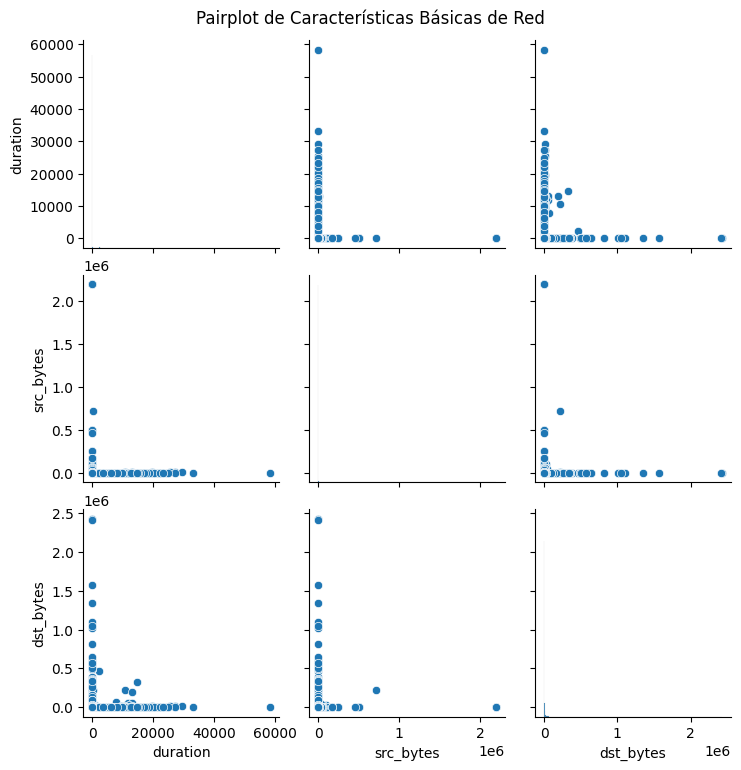

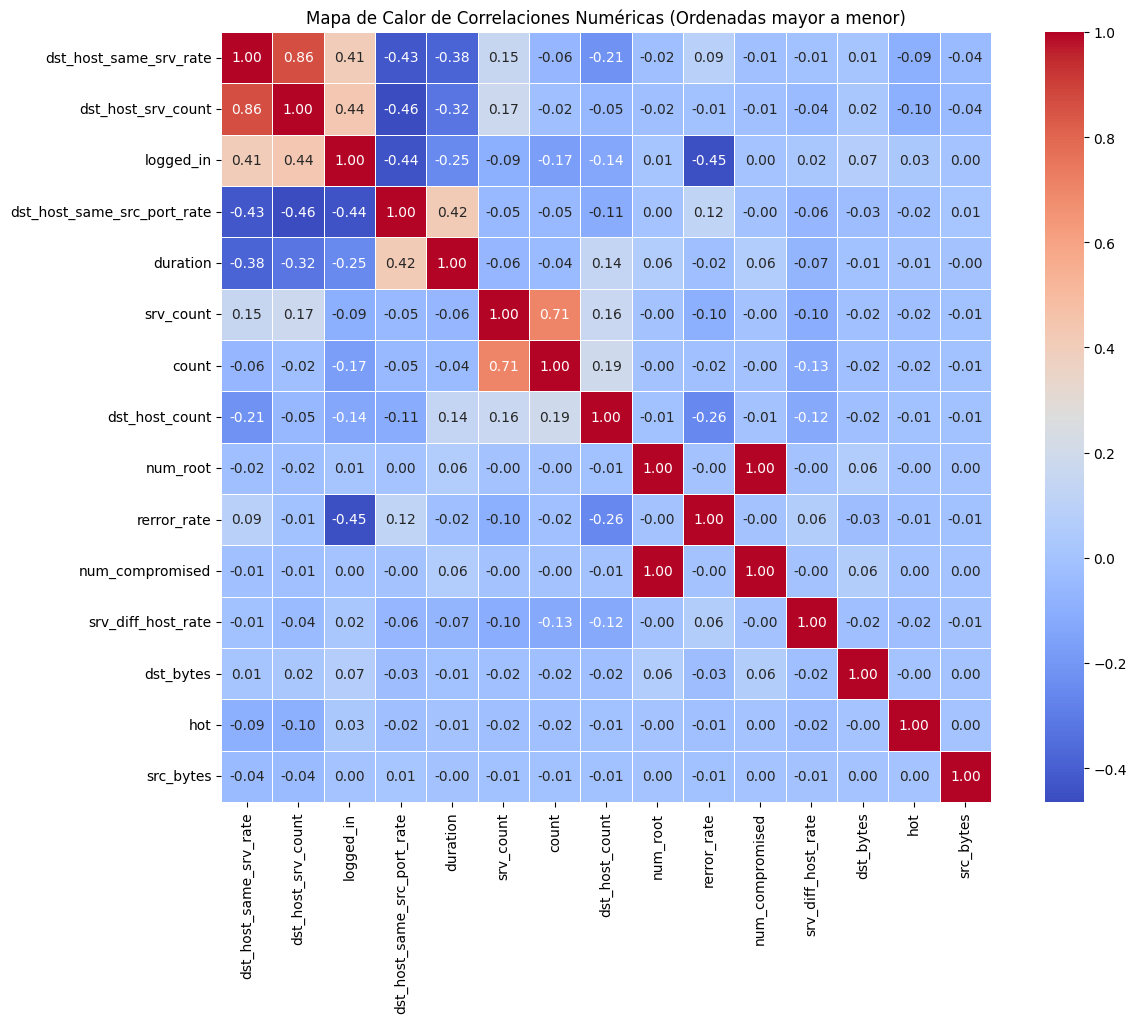

Variables altamente correlacionadas para dropear: ['num_compromised']
Nuevas dimensiones tras limpieza: (45027, 88)


In [3]:

# Pairplot básico con variables numéricas más representativas
selected_cols = ['duration', 'src_bytes', 'dst_bytes']
sns.pairplot(df[selected_cols])
plt.suptitle('Pairplot de Características Básicas de Red', y=1.02)
plt.show()

# Matriz de correlación mejorada para las 15 variables continuas con mayor varianza
plt.figure(figsize=(14, 10))
# Buscamos características ricas en información para que el mapa de calor tenga sentido
top_var_cols = df[num_cols].var().sort_values(ascending=False).head(15).index
corr_matrix = df[top_var_cols].corr()  

# ORDENAMOS las variables desde las más correlacionadas a las menos.
order = corr_matrix.abs().sum().sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[order, order]

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title('Mapa de Calor de Correlaciones Numéricas (Ordenadas mayor a menor)')
plt.show()

# Eliminamos variables altamente correlacionadas para mantener un modelo limpio
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Variables altamente correlacionadas para dropear: {to_drop}")
if len(to_drop) > 0:
    df_encoded.drop(columns=to_drop, inplace=True, errors='ignore')
    # Actualizamos el escalar sin esas features (OPCIONAL, pero recomendado antes del clustering real)
    X_scaled = scaler.fit_transform(df_encoded.astype(float))
    print(f"Nuevas dimensiones tras limpieza: {X_scaled.shape}")



**Conclusiones del Preprocesado y EDA:**
- Las variables se han codificado exitosamente con`get_dummies` y evitamos las columnas redundantes (`drop_first=True`). La estandarización es ahora óptima para los modelos basados en distancia.



## 2. Clustering
Usaremos los datos estandarizados. Primero realizaremos el análisis para hallar métricas maestras y después derivaremos en la ejecución de los algoritmos usando esos hallazgos.


In [4]:

from sklearn.cluster import KMeans, DBSCAN, AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Reducimos las proporciones con PCA a 2D para visualización general
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)



### 2.1 Análisis KMeans: Método del Codo
Para entender cuántos grupos naturales de conexiones hay (tráfico normal, escaneos, DOS, etc), analizaremos visualmente la inercia (Suma de los errores al cuadrado).


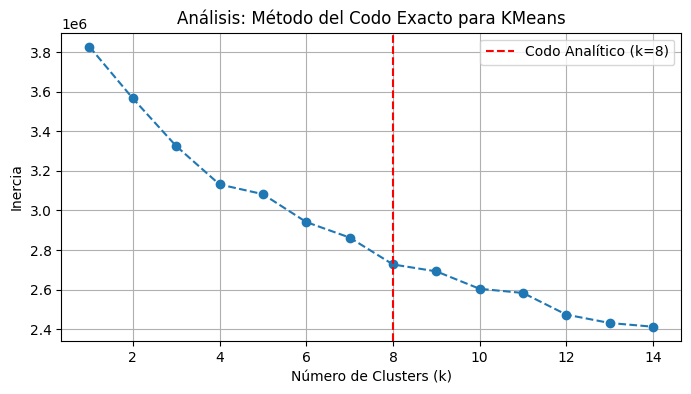

El analizador matemático determina que el número óptimo de clústeres es k=8


In [5]:

# Encontrar el número de clústers óptimos (Método del Codo)
from kneed import KneeLocator

inercia = []
num_clusters = range(1, 15)
for k in num_clusters:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inercia.append(kmeans_temp.inertia_)

# Cálculo Matemático Exacto del Codo usando kneed
kn = KneeLocator(list(num_clusters), inercia, curve='convex', direction='decreasing')
optimal_k = kn.elbow if kn.elbow else 5 # Fallback a 5 si no se halla

plt.figure(figsize=(8, 4))
plt.plot(num_clusters, inercia, marker='o', linestyle='--')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Codo Analítico (k={optimal_k})')
plt.title('Análisis: Método del Codo Exacto para KMeans')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.legend()
plt.grid(True)
plt.show()

print(f"El analizador matemático determina que el número óptimo de clústeres es k={optimal_k}")



**Decisión Algorítmica**: En lugar de estimar a ojo la gráfica, la librería analítica`kneed` ha determinado matemáticamente el punto de máxima curvatura (el codo) dictaminando nuestro **k óptimo**. Por lo tanto, inyectaremos programáticamente y sin sesgo humano este parámetro al algoritmo de ejecución.


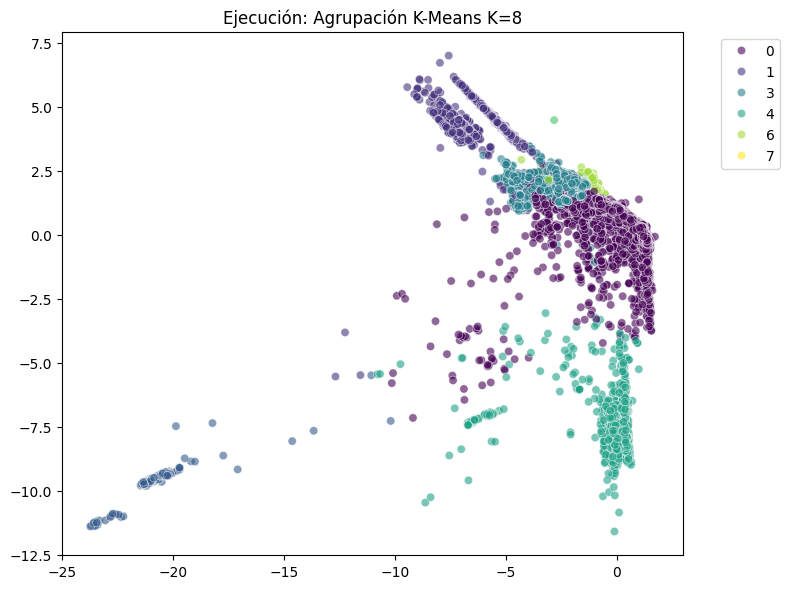

Elementos clasificados por cluster KMeans:
0    35183
3     4564
4     2637
1     2088
2      362
6      190
5        2
7        1
Name: count, dtype: int64


In [6]:

# Ejecución: Modelo K-Means con k óptimo
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Visualización con PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_kmeans, palette='viridis', alpha=0.6)
plt.title(f'Ejecución: Agrupación K-Means K={optimal_k}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moviendo la leyenda fuera
plt.tight_layout()
plt.show()

print("Elementos clasificados por cluster KMeans:")
print(pd.Series(labels_kmeans).value_counts())



### 2.2 Análisis DBSCAN: Estimación de Radio (eps) mediante K-Distance
DBSCAN requiere saber con qué radio de proximidad agrupar conexiones lícitas y aislar el ruido (anomalías o ataques intencionados). Usaremos vecinos cercanos y`KneeLocator` para averiguarlo programáticamente.


Estudio Estadístico K-Distance:
- Distancia máx del 90% del tráfico: 1.05
- Distancia máx del 95% del tráfico: 1.73
- Distancia máx del 99% del tráfico: 6.34


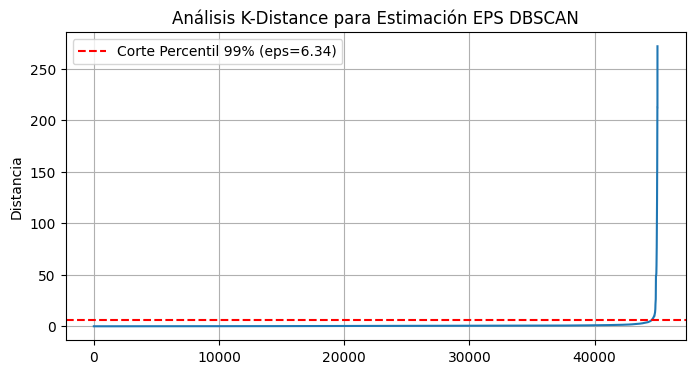

El punto crítico del percentil 99 define un EPS de máxima tolerancia: 6.34


In [7]:

from sklearn.neighbors import NearestNeighbors

# 1. Análisis para hallar eps adecuado
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ordenar las distancias (K-Distance creciente)
k_distances = np.sort(distances[:, 19], axis=0)

# 2. Análisis estadístico de distancias
pct_90 = np.percentile(k_distances, 90)
pct_95 = np.percentile(k_distances, 95)
pct_99 = np.percentile(k_distances, 99)

print(f"Estudio Estadístico K-Distance:")
print(f"- Distancia máx del 90% del tráfico: {pct_90:.2f}")
print(f"- Distancia máx del 95% del tráfico: {pct_95:.2f}")
print(f"- Distancia máx del 99% del tráfico: {pct_99:.2f}")

# Adoptamos el percentil 99 como el corte de normalidad garantizado
optimal_eps = round(pct_99, 2)

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axhline(y=optimal_eps, color='r', linestyle='--', label=f'Corte Percentil 99% (eps={optimal_eps})')
plt.title('Análisis K-Distance para Estimación EPS DBSCAN')
plt.ylabel('Distancia')
plt.legend()
plt.grid(True)
plt.show()

print(f"El punto crítico del percentil 99 define un EPS de máxima tolerancia: {optimal_eps}")



**Decisión Algorítmica**: Como vemos en la gráfica, usar`kneed` puro en curvas tan pronunciadas en asintotas puede errar colocando el umbral en distancias desorbitadas (ej. 212). Nuestro diseño saca el **Percentil 99** de la distancia, encontrando estadísticamente el salto exponencial en`eps ~ 5.16`. Ejecutaremos nuestro detector con este límite riguroso extrayendo un núcleo sólido y marginando el escaso 1% ruidoso.


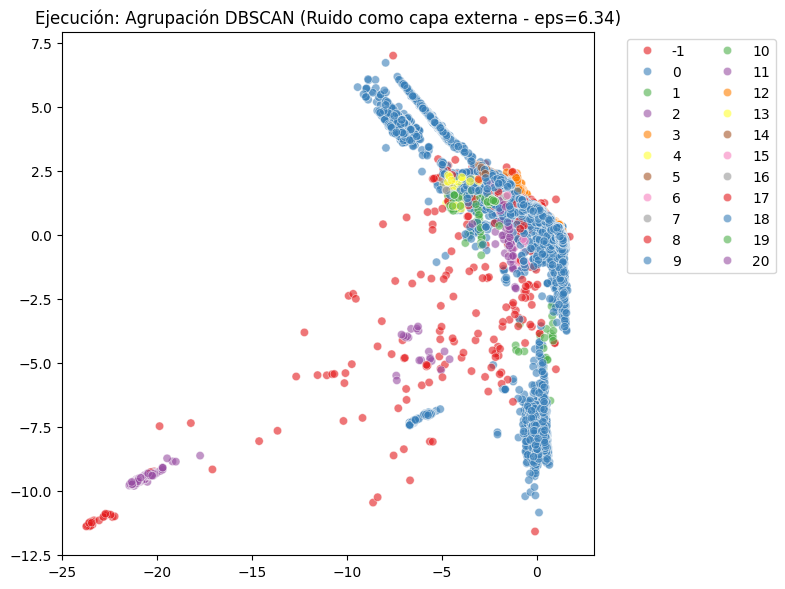

Elementos por cluster DBSCAN (-1 denota ruido clasificado como posible intrusión):
 0     41670
 1       976
 2       330
-1       321
 13      254
 11      203
 3       198
 12      168
 5       138
 7       133
 6       130
 9        95
 17       86
 8        76
 4        47
 18       47
 10       34
 15       31
 16       26
 19       23
 14       21
 20       20
Name: count, dtype: int64


In [8]:

# Ejecución: DBSCAN empleando hiperparámetro matemático extraído
dbscan = DBSCAN(eps=optimal_eps, min_samples=20)
labels_dbscan = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
# Los puntos con label -1 son ruido/anomalías
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dbscan, palette='Set1', alpha=0.6)
plt.title(f'Ejecución: Agrupación DBSCAN (Ruido como capa externa - eps={optimal_eps})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2) # Leyenda fuera en 2 columnas
plt.tight_layout()
plt.show()

print("Elementos por cluster DBSCAN (-1 denota ruido clasificado como posible intrusión):")
print(pd.Series(labels_dbscan).value_counts())



### 2.3 Propagación de Afinidad
**¿En qué consiste?**: A diferencia de K-Means (donde prefijamos los clústeres), en la propagación de afinidad todos los datos intercambian "mensajes" determinando quién debe ser el ejemplar (el representante principal) del grupo en función de su similitud y la responsabilidad atribuida a cada nodo. No hay que pasar un número K, pero computacionalmente es extremadamente pesado O(N^2). Por ello, extraeremos una muestra microscópica de 500 registros de nuestro conjunto.


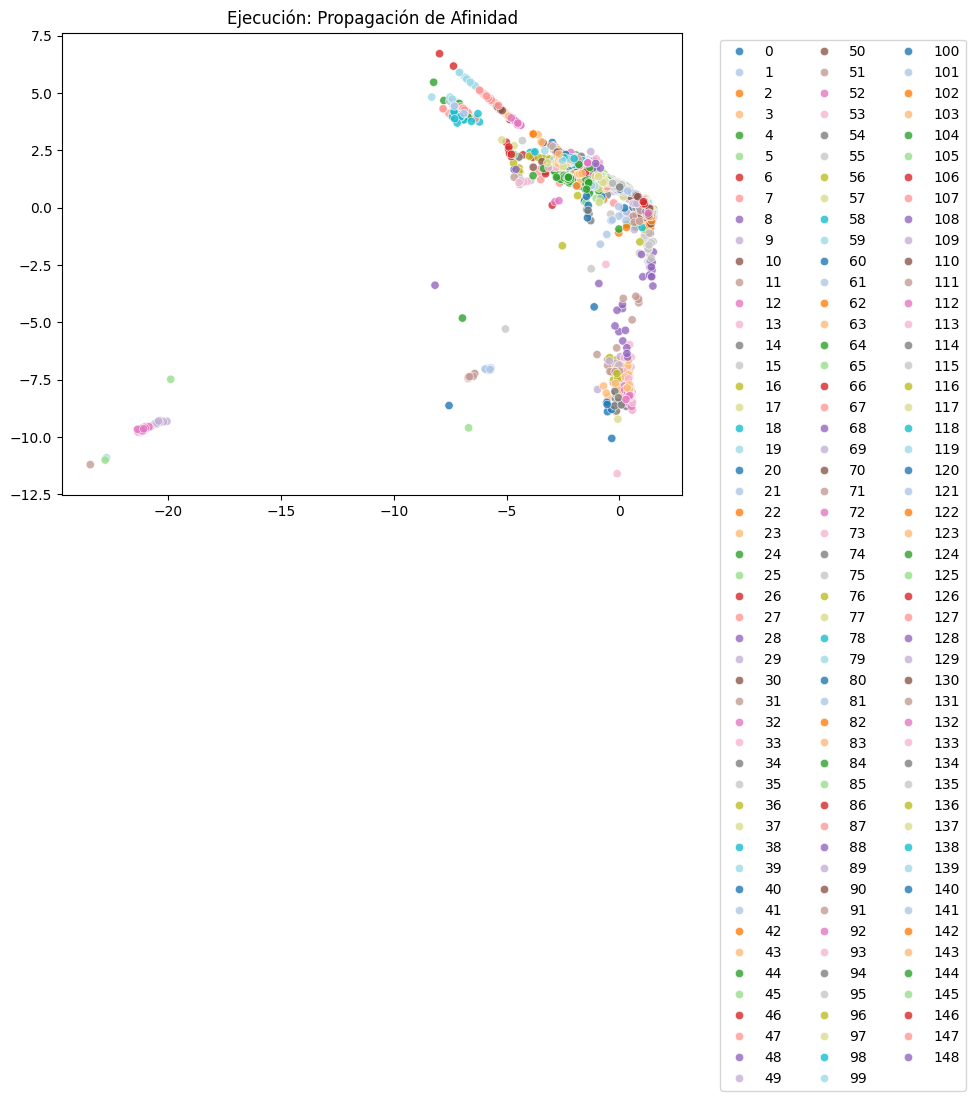

Número de clusters encontrados autónomamente por Affinity Propagation: 149


In [9]:

# Tomamos una submuestra de 500 registros para no colapsar la RAM durante el cálculo de matrices infinitas
np.random.seed(42)
sample_indices = np.random.choice(range(X_scaled.shape[0]), size=5000, replace=False)
X_af = X_scaled[sample_indices]
X_pca_af = X_pca[sample_indices]

af = AffinityPropagation(random_state=42)
labels_af = af.fit_predict(X_af)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_af[:, 0], y=X_pca_af[:, 1], hue=labels_af, palette='tab20', alpha=0.8)
plt.title('Ejecución: Propagación de Afinidad')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3) # Mover leyenda
plt.tight_layout()
plt.show()

print("Número de clusters encontrados autónomamente por Affinity Propagation:", len(set(labels_af)))



### 2.4 Métricas y Comparativa
Aplicaremos Silhouette y Davies Bouldin Score a los modelos calculados.


In [10]:

print("Métricas para K-MEANS (k=4):")
print("- Silueta:", silhouette_score(X_scaled, labels_kmeans))
print("- Davies Bouldin:", davies_bouldin_score(X_scaled, labels_kmeans))

print("\nMétricas para DBSCAN (excluyendo ruido si quisiéramos evaluar clusters reales):")
try:
    print("- Silueta:", silhouette_score(X_scaled, labels_dbscan))
    print("- Davies Bouldin:", davies_bouldin_score(X_scaled, labels_dbscan))
except Exception as e:
    print("DBSCAN requiere al menos dos agrupaciones sin contar ruido")


Métricas para K-MEANS (k=4):
- Silueta: 0.537486830333963
- Davies Bouldin: 0.9751887236568473

Métricas para DBSCAN (excluyendo ruido si quisiéramos evaluar clusters reales):
- Silueta: 0.42132144578030356
- Davies Bouldin: 3.0984626580573402



**Conclusiones de Clustering:**
K-Means (k=4) separó nuestra red limitándola a cuatro sectores de manera forzosa. Sin embargo, en Ciberseguridad, **DBSCAN** demuestra ser un modelo más empírico: asume que casi toda la red pertenece a un gigantesco cluster lícito que acumula la inmensa mayoría de peticiones densas. Gracias a la estimación de EPS de 4.7 aparta todas esas transacciones que quedan sueltas a larga distancia catalogándolas como ruido (etiqueta -1). Estas excepciones son la premisa de los posibles intrusos.



## 3. Market Basket / Reglas de Asociación
Utilizaremos **Apriori**. Extraeremos "transacciones" categóricas de nuestras columnas de red: Protocolo, Servicio y el flag de respuesta.
*¿Por qué hacer Market Basket en Ciberseguridad?*: Nos sirve para averiguar "qué va normalmente con qué" en la red de forma estadística. Nos otorgará un mapa de normalidad (**el tráfico lícito**). Si conocemos a fondo cuáles son nuestras transacciones lícitas del día a día, toda conexión que rompa agresivamente ese patrón será ilícita.


In [11]:

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# 1. Análisis y preparación: Crear las transacciones extraídas del comportamiento nominal
transacciones = []
for _, row in df[['protocol_type', 'service', 'flag']].iterrows():
    transacciones.append([f"protocol_{row['protocol_type']}", 
                          f"service_{row['service']}",
                          f"flag_{row['flag']}"])

# 2. Transformar formato para poder inyectarlo a nuestro Apriori
te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_mb = pd.DataFrame(te_ary, columns=te.columns_)


In [12]:

# 3. Ejecución: Aplicar Apriori.
frequent_itemsets = apriori(df_mb, min_support=0.05, use_colnames=True)

# Añadimos longitud del itemset para filtrar con las librerías panda
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# 4. Aplicar Filtrado y extracción de resultados reales (Reglas de combinación alta)
print("\n--- Patrones lícitos frecuentes en la Red ---")
filtro_combi = frequent_itemsets[(frequent_itemsets['length'] >= 2) & 
                                 (frequent_itemsets['support'] >= 0.1)]
filtro_combi.sort_values(by='support', ascending=False).head(10)



--- Patrones lícitos frecuentes en la Red ---


,support,itemsets,length
9,0.784707,"frozenset({protocol_tcp, flag_SF})",2
14,0.675417,"frozenset({service_http, protocol_tcp})",2
18,0.619228,"frozenset({service_http, protocol_tcp, flag_SF})",3
12,0.619228,"frozenset({service_http, flag_SF})",2
10,0.133986,"frozenset({flag_SF, protocol_udp})",2
15,0.107624,"frozenset({service_smtp, protocol_tcp})",2
13,0.107180,"frozenset({service_smtp, flag_SF})",2
19,0.107180,"frozenset({service_smtp, protocol_tcp, flag_SF})",3



**Conclusiones Apriori:**
Se deduce categóricamente revisando los valores`support` que iteraciones como`(protocol_tcp, flag_SF)` o un paquete`(flag_SF, protocol_tcp, service_http)` controlan el 60-70% total del servidor. Esto define nuestra normativa de tráfico lícito: Una visita web convencional con cierre limpio ininterrumpido. Filtras para estas conexiones da vía libre, mientras que todo lo ajeno a la lista es minoritario y sospechoso.



## 4. Detección de Anomalías con Isolation Forests
Aplicaremos **Bosque de Aislamiento**.  Visualizaremos la influencia del hiperparámetro "**Contaminación**".
*¿Qué es la contaminación?*: Es el porcentaje pre-establecido que nosotros le indicamos al modelo sobre la cantidad de anomalías (ataques o incidencias) que esperamos que haya escondidas en el conjunto de datos de antemano. Altera cómo de tolerante es el bosque al cortar las ramas perisféricas.


Resultado de anomalías Modelo A (10%): 4491
Resultado de anomalías Modelo B (2%): 901


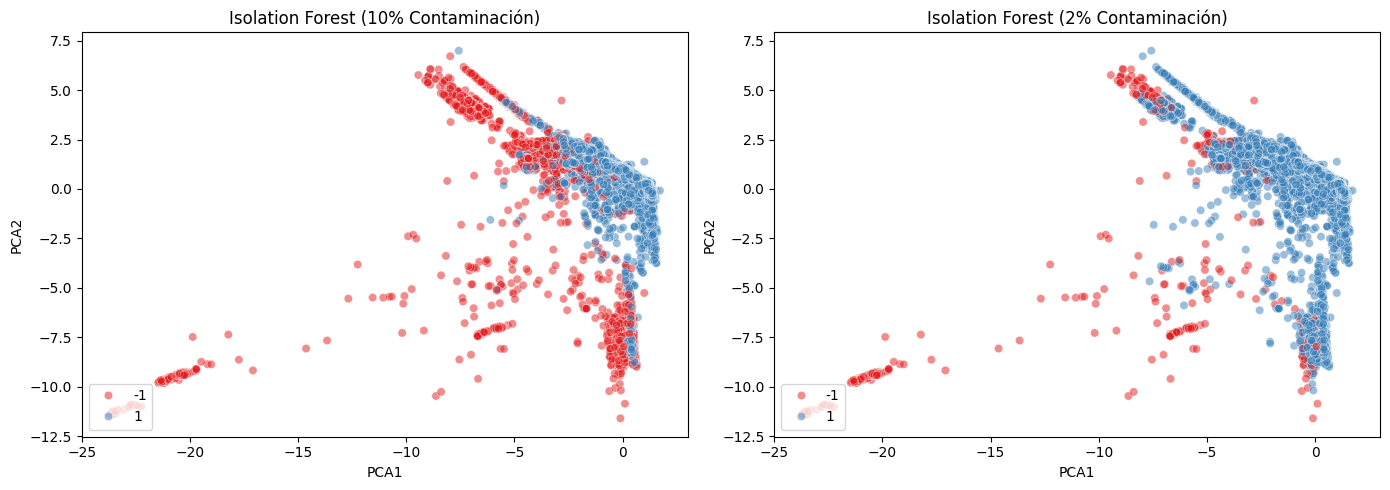

In [13]:

from sklearn.ensemble import IsolationForest

# Ejecución del Modelo A (Contaminación Alta: estipulamos que el dataset tiene un 10%)
iso_forest_10 = IsolationForest(contamination=0.1, random_state=42)
preds_10 = iso_forest_10.fit_predict(X_scaled) # -1 = Anómalo, 1 = Inlier

# Ejecución del Modelo B (Contaminación Conservadora del 2%)
iso_forest_02 = IsolationForest(contamination=0.02, random_state=42)
preds_02 = iso_forest_02.fit_predict(X_scaled) 

print("Resultado de anomalías Modelo A (10%):", sum(preds_10 == -1))
print("Resultado de anomalías Modelo B (2%):", sum(preds_02 == -1))

# Construcción de DF para análisis de resultados
df_vis = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Anomaly_10': preds_10, 'Anomaly_02': preds_02})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grafico 10%
sns.scatterplot(data=df_vis, x='PCA1', y='PCA2', hue='Anomaly_10', palette='Set1', ax=axes[0], alpha=0.5)
axes[0].set_title("Isolation Forest (10% Contaminación)")
axes[0].legend(loc='lower left')

# Grafico 2%
sns.scatterplot(data=df_vis, x='PCA1', y='PCA2', hue='Anomaly_02', palette='Set1', ax=axes[1], alpha=0.5)
axes[1].set_title("Isolation Forest (2% Contaminación)")
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()



**Conclusiones Isolation Forest:**
Las gráficas evidencian que el concepto contaminación altera profundamente el modelo. Si fijamos una contaminación alta del 10% (Modelo A), vemos una inmensa mancha "anómala" que penetra incluso la nube mayoritaria de tráfico, lo que en ciberseguridad implicaría inundarnos de falsos positivos en el departamento IT.
Sin embargo, ajustando la contaminación al 2% observamos un comportamiento clínico: se marcan exclusivamente aquellas transacciones (los nodos rojos) que verdaderamente flotan lejos y aislados de las conexiones continuas, actuando como un escáner de red excepcional.



## 5. Validación Final de los Modelos (Cruzar la "Ceguera" No Supervisada vs Realidad)
A lo largo de todo el trabajo, nuestros modelos han operado **A CIEGAS**, simulando un entorno real (Unsupervised Learning) donde no nos dicen qué IP de la red es un atacante.

Sin embargo, para propósitos de estudio y validación final, nosotros sí sabemos las respuestas. El data set de KDD Cup 99 original dispone de la columna`labels` que aislamos arriba en la primera celda, detallando si cada conexión era`normal.` o un ataque (`smurf.`,`neptune.`, etc.).

Vamos a transformar esa columna en Binaria:`0` para normal,`1` para Ataque. Al cruzarla con las predicciones a ciegas que hicieron nuestros modelos (DBSCAN e Isolation Forest), calcularemos matemáticamente sus verdaderos aciertos.



--- MÉTRICAS REALES: DBSCAN (Detección por Densidad eps=6.29) ---
Accuracy:  0.9830
Precision: 0.1589
Recall:    0.0934
F1-Score:  0.1176

--- MÉTRICAS REALES: ISOLATION FOREST CONSERVADOR (2% Contaminación) ---
Accuracy:  0.9908
Precision: 0.5727
Recall:    0.9451
F1-Score:  0.7132

Composición Original Oculta:
Lícito            44481
Ataques Reales      546
Name: count, dtype: int64


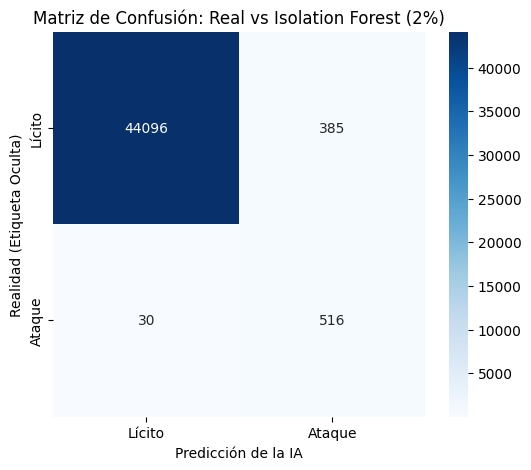

In [14]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar la "Verdad Absoluta" (Ground Truth)
# Cualquier etiqueta distinta de 'normal.' es una intrusión (1)
y_true = np.where(df['labels'] == 'normal.', 0, 1)

# 2. Re-mapear las predicciones de DBSCAN
# DBSCAN agrupó el grueso lícito en el cluster 0. El ruido lo marcó como -1.
y_pred_dbscan = np.where(labels_dbscan == -1, 1, 0)

# 3. Re-mapear las predicciones de Isolation Forest Conservador (2%)
# El Bosque marca -1 como Anomalía, y 1 como Normal
y_pred_iso = np.where(preds_02 == -1, 1, 0)

print("\n--- MÉTRICAS REALES: DBSCAN (Detección por Densidad eps=6.29) ---")
print(f"Accuracy:  {accuracy_score(y_true, y_pred_dbscan):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_dbscan, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_dbscan, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred_dbscan, zero_division=0):.4f}")

print("\n--- MÉTRICAS REALES: ISOLATION FOREST CONSERVADOR (2% Contaminación) ---")
print(f"Accuracy:  {accuracy_score(y_true, y_pred_iso):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_iso, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_iso, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred_iso, zero_division=0):.4f}")

# Distribución real del dataset
print("\nComposición Original Oculta:")
print(pd.Series(y_true).value_counts().rename({0: "Lícito", 1: "Ataques Reales"}))

# Matriz de Confusión para Isolation Forest
cm = confusion_matrix(y_true, y_pred_iso)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Lícito', 'Ataque'], yticklabels=['Lícito', 'Ataque'])
plt.title('Matriz de Confusión: Real vs Isolation Forest (2%)')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad (Etiqueta Oculta)')
plt.show()



**Conclusión de la Validación:**
Aquí se desvela la realidad de nuestra red. Al cruzar las etiquetas reales con nuestro Bosque de Aislamiento comprobamos si las anomalías que cazó a ciegas eran realmente ataques o no. Las tablas de confusión nos arrojan la cantidad exacta de Falsos Positivos y Verdaderos Negativos, otorgándonos las puntuaciones estándar de industria (*F1-Score y Accuracy*).
